In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation
import random

In [2]:
W = 5
H = 5
REWARDS = np.zeros((H,W))
REWARDS[0,1] = 10
REWARDS[0,3] = 5

V = np.zeros((H,W))
gamma = 0.9
actions = ["L","R","U","D"]
pi = [0.25,0.25,0.25,0.25]


In [3]:
#Returns probability distribution(dict) of possible states and the reward
#state is a len 2 array (row,col)
#action is one of "L","R","U","D"
def get_transition(state, action):
    if state == (0,1):
        return {(4,1): 1.0}, 10
    elif state == (0,3):
        return {(2,3): 1.0}, 5
    elif (state[0] == 0 and action == "U") or (state[0] == 4 and action == "D") or (state[1] == 0 and action == "L") or (state[1] == 4 and action == "R"):
        return {state: 1.0}, -1
    else: 
        if state[0] == 4:
            if action == "R":
                return {(state[0],state[1]+1): 1.0}, 0
            elif action == "L":
                return {(state[0],state[1]-1): 1.0}, 0
            elif action == "U":
                return {(state[0]-1,state[1]): 1.0}, 0
        else:
            if action == "R":
                return {(state[0],state[1]+1): 0.9,
                        (state[0]+1,state[1]): 0.1}, 0
            elif action == "L":
                return {(state[0],state[1]-1): 0.9,
                        (state[0]+1,state[1]): 0.1}, 0
            elif action == "U":
                return {(state[0]-1,state[1]): 0.9,
                        (state[0]+1,state[1]): 0.1}, 0
            elif action == "D":
                return {(state[0]+1,state[1]): 1.0}, 0

    
    

In [4]:
def calc_v(state):
    new_v = 0
    for i in range(len(actions)):
        probability_dict, reward = get_transition(state, actions[i])
        for next_state in probability_dict:
            new_v += pi[i] * probability_dict[next_state] * (reward + gamma * V[next_state[0]][next_state[1]])
    return new_v

In [5]:
threshold = 0.0001
while True:
    delta = 0
    new_V = np.copy(V)
    for row in range(H):
        for col in range(W):
            new_V[row,col] = calc_v((row, col))
            delta = max(delta, abs(new_V[row,col]-V[row,col]))
    V = new_V
    if delta < threshold:
        break
print(np.round(V,2))

[[ 2.47  8.43  3.57  4.69  0.71]
 [ 0.62  2.09  1.34  1.07 -0.23]
 [-0.71 -0.04 -0.08 -0.35 -1.07]
 [-1.57 -1.02 -0.93 -1.13 -1.72]
 [-2.26 -1.75 -1.62 -1.8  -2.35]]


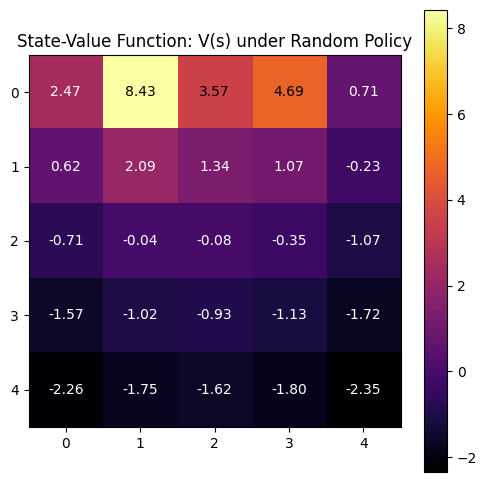

: 

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

cax = ax.imshow(V, cmap='inferno', interpolation='nearest')

for r in range(H):
    for c in range(W):
        text = ax.text(c, r, f"{V[r, c]:.2f}",
                       ha="center", va="center", color="w" if V[r,c] < 3 else "black")

plt.colorbar(cax)
plt.title("State-Value Function: V(s) under Random Policy")
plt.show()